In [97]:
# Setup
%load_ext autoreload
%autoreload 2

import logging
import os
import random
from pathlib import Path
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import Config
from macro_data import DataWrapper
from macro_data.configuration import DataConfiguration, split_country_configs
from macro_data.configuration_utils import default_data_configuration, read_country_conf
from macromodel.configurations import CountryConfiguration, SimulationConfiguration
from macromodel.simulation import Simulation
from macromodel.util.loader import Loader
from src.helpers import align_country_configuration_to_data, unpack_cell
from src.visual_helpers import build_macro_output_df, plot_output

logging.getLogger().setLevel(logging.ERROR)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [98]:
# Load config
cfg = Config().from_env()
raw_data_path = cfg.raw_data_path or Path('data/hfcs/raw')
output_dir = cfg.output_path or Path('data/output')
output_dir.mkdir(parents=True, exist_ok=True)
data_pkl_path = output_dir / 'data.pkl'
model_h5_path = output_dir / f"simulation_{cfg.country_iso3}.h5"


In [99]:
def plot_histogram(values, label, t=-1, bins=40):
    step_label = values.shape[0] - 1 if t == -1 else t

    x = values[t]
    x = x[np.isfinite(x)]

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.hist(
        x,
        bins=bins,
        weights=np.ones_like(x) / len(x),
        edgecolor="black",
    )

    ax.set_title(f"{label} distribution, step {step_label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Share of households")

    fig.tight_layout()
    plt.show()


def plot_distribution_summary(values, label, bins=40, t=-1):
    step = values.shape[0] - 1 if t == -1 else t

    x = values[step]
    x = x[np.isfinite(x)]

    hist_over_time = []
    for row in values:
        row = row[np.isfinite(row)]
        hist, _ = np.histogram(row, bins=bins)
        hist = hist / hist.sum()
        hist_over_time.append(hist)

    hist_over_time = np.asarray(hist_over_time)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Native empirical CDF from raw data
    axes[0].ecdf(x)
    axes[0].set_title(f"{label} CDF, step {step}")
    axes[0].set_xlabel(label)
    axes[0].set_ylabel("Cumulative share")
    axes[0].set_ylim(0, 1)
    axes[0].grid(alpha=0.3)

    # Dynamic histogram evolution from raw data
    im = axes[1].imshow(
        hist_over_time.T,
        aspect="auto",
        origin="lower",
        interpolation="nearest",
    )
    axes[1].set_title(f"{label} distribution over time")
    axes[1].set_xlabel("Simulation step")
    axes[1].set_ylabel(f"{label} bin")

    fig.colorbar(im, ax=axes[1], label="Share of households")

    fig.tight_layout()
    plt.show()



### Distribution of income and wealth against HFCS

In [100]:
import h5py

with h5py.File(model_h5_path, "r") as f:
    # print(list(f.keys()))              # top-level groups
    # for key in f["FRA"].keys():
    #     print(key)
    # for key in f["FRA"]['households'].keys():
    #     print(key)

    income = f["FRA"]['households']['income'][:]
    # income_hist = f["FRA"]['households']['income_histogram'][:]
    wealth = f["FRA"]['households']['wealth'][:]
    # wealth_hist = f["FRA"]['households']['wealth_histogram'][:]

print(income.shape)
# print(income_hist.shape)
print(wealth.shape)
# print(wealth_hist.shape)


(51, 2880)
(51, 2880)


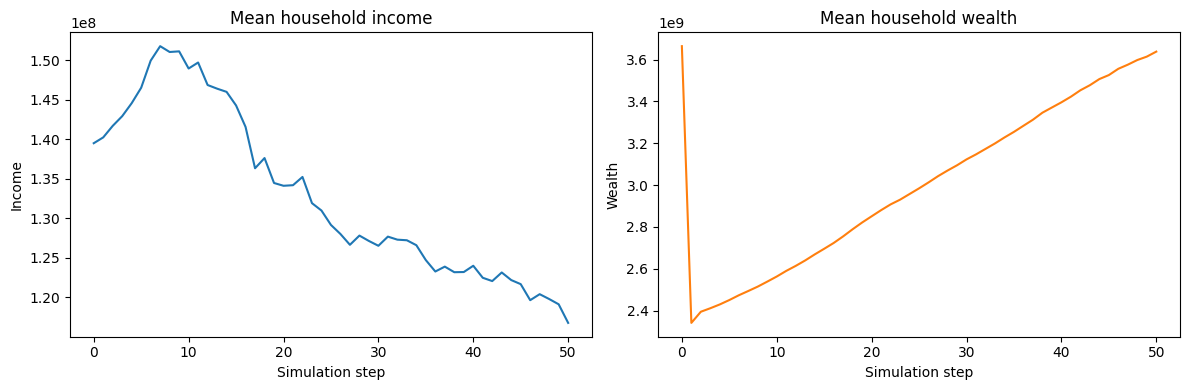

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(income.mean(axis=1))
axes[0].set_title("Mean household income")
axes[0].set_xlabel("Simulation step")
axes[0].set_ylabel("Income")

axes[1].plot(wealth.mean(axis=1), color="tab:orange")
axes[1].set_title("Mean household wealth")
axes[1].set_xlabel("Simulation step")
axes[1].set_ylabel("Wealth")

fig.tight_layout()
plt.show()


In [102]:
# To do:
# Rescale values by the scale value in model config (data_config_FRA.yaml)
# Trim the distribution of income and wealth to the 99% percentile
# Determine the starting year of the simulation.
# Load HFCS data from waves (e.g. 2014, 2017, 2021) greater or equal than the starting year of the simulation
# Make sure income and wealth are comparable between HFCS and model (e.g. net-gross)
# Compare the distribution of income and wealth. Try the following: 
#   -  histograms on the same chart for model and data (one CDF for income, one for wealth)
#   -  histograms on subplots vertically aligned for model and data
#   -  CDF on the same plot for model and data (one CDF for income, one for wealth)
# those charts should go onto an online dashboard in streamlit. Make sure they are optimised for that

# next steps: 
# compare mean liquid and illiquid asset to gdp ratios to the correspondent ratio in data: histograms
# lorentz curve for liquid and illiquid wealth, model vs data


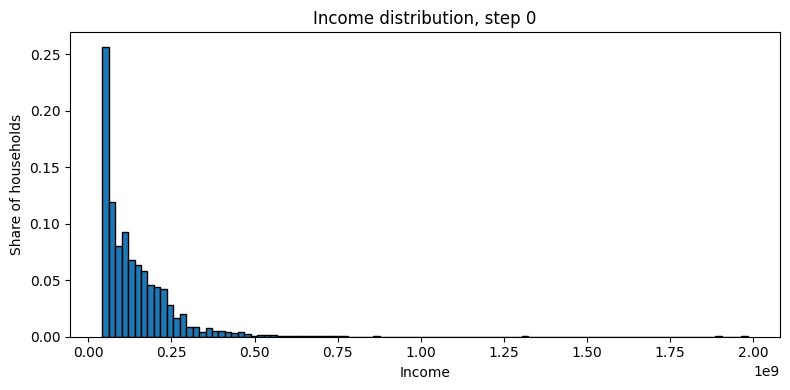

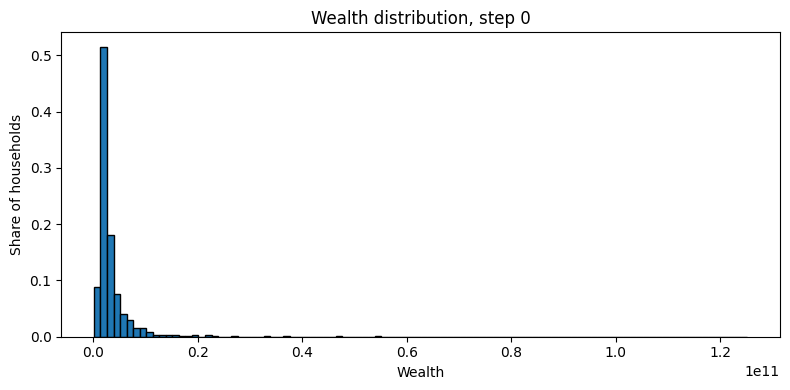

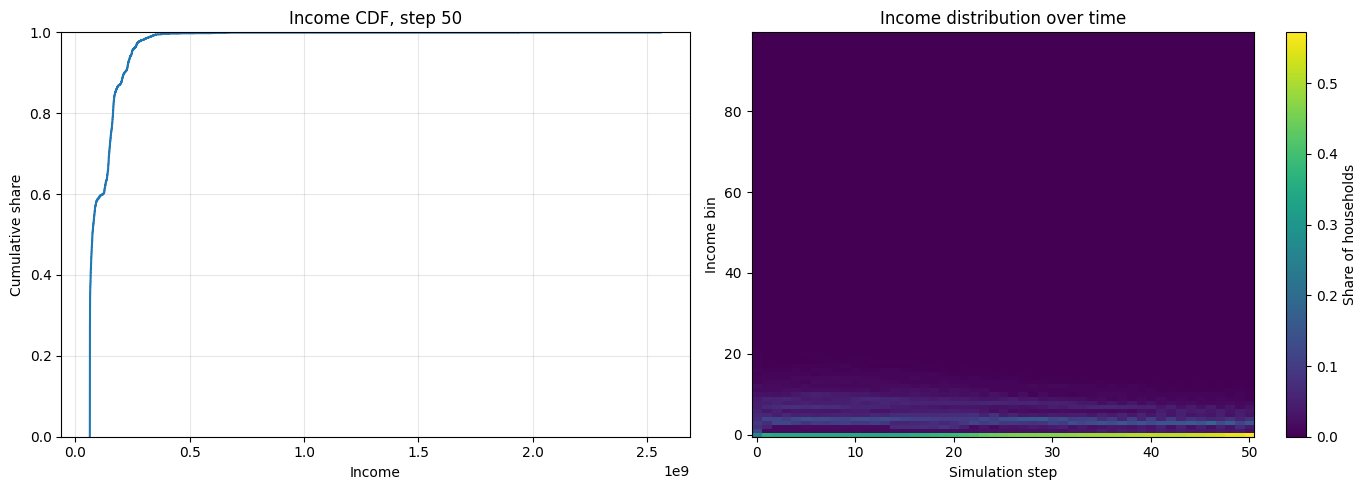

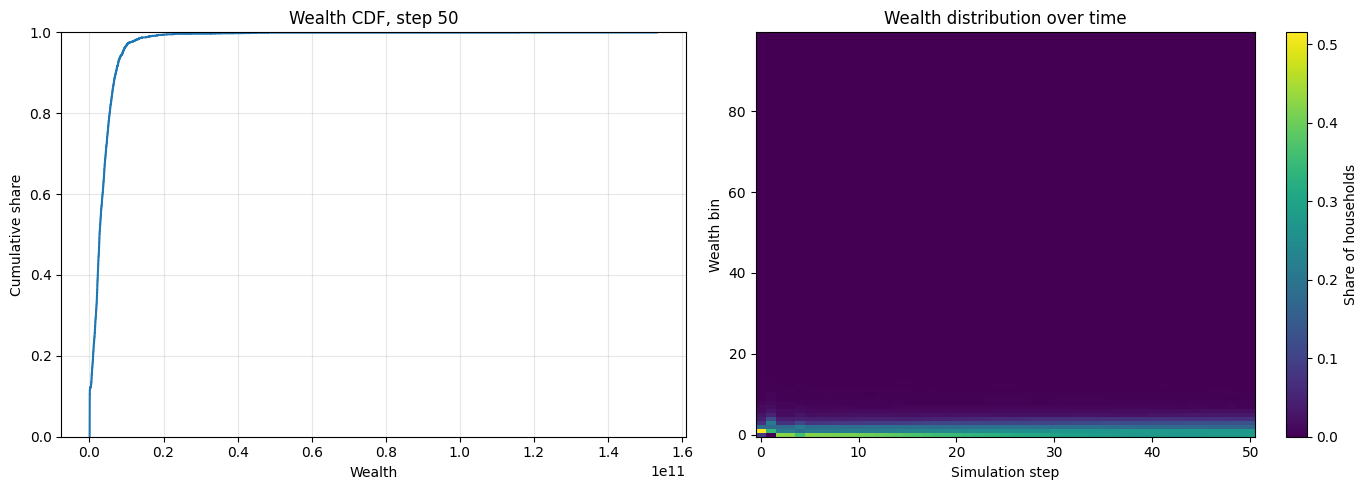

In [103]:
from macromodel.util.get_histogram import get_histogram

# t = -1  # final simulation step
n_bins = 100

# t = income_counts.shape[0] - 1
t = 0

plot_histogram(income, "Income", t=t, bins=n_bins)
plot_histogram(wealth, "Wealth", t=t, bins=n_bins)

plot_distribution_summary(income, "Income", bins=n_bins)
plot_distribution_summary(wealth, "Wealth", bins=n_bins)



### Distribution of MPCs

### Impulse response functions